In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

In [ ]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(f"Folder: {dirname}")
    print(f"Number of files: {len(filenames)}")
    print("-" * 60)

    if len(filenames) > 0:
        print("Sample files:")
        print(filenames[:5])
        print("=" * 60)

In [ ]:
import os

jpg_count = 0

for dirname, _, filenames in os.walk('/kaggle/input'):
    
    jpg_files = [f for f in filenames if f.lower().endswith('.jpg')]
    
    if len(jpg_files) > 0:
        print("\nFOUND IMAGE FOLDER:")
        print(dirname)
        print("Number of JPG files:", len(jpg_files))
        print("Sample Images:", jpg_files[:5])
        
        jpg_count += len(jpg_files)

print("\nTotal JPG Images Found:", jpg_count)

In [ ]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

print("Contents of fashion-dataset folder:")
print(os.listdir(base_path))

In [ ]:
import os

image_folder = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

files = os.listdir(image_folder)

print("Total files:", len(files))
print("\nFirst 10 files:")
print(files[:10])

In [ ]:
import pandas as pd

csv_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv"

df = pd.read_csv(csv_path, on_bad_lines='skip')

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

In [ ]:
print("Missing Values Per Column:\n")

print(df.isnull().sum())

In [ ]:
article_counts = df['articleType'].value_counts()

print("Number of Unique Article Types:")
print(df['articleType'].nunique())

print("\nTop 20 Article Types:")
print(article_counts.head(20))

In [ ]:
import os

# Image folder path
image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

# Top 15 classes
top_classes = df['articleType'].value_counts().head(15).index.tolist()

print("Top 15 Classes:")
print(top_classes)

# Keep only top 15 classes
df_filtered = df[df['articleType'].isin(top_classes)].copy()

# Create image path column
df_filtered['image_path'] = df_filtered['id'].astype(str) + ".jpg"

# Check if image exists
df_filtered['image_exists'] = df_filtered['image_path'].apply(
    lambda x: os.path.exists(os.path.join(image_dir, x))
)

# Keep only rows with existing images
df_filtered = df_filtered[df_filtered['image_exists']]

print("\nFiltered Dataset Shape:")
print(df_filtered.shape)

print("\nNumber of Classes:")
print(df_filtered['articleType'].nunique())

print("\nClass Distribution:")
print(df_filtered['articleType'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_df = df_filtered.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    
    img_path = os.path.join(
        image_dir,
        f"{row['id']}.jpg"
    )
    
    img = Image.open(img_path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row['articleType'])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df_filtered,
    test_size=0.30,
    stratify=df_filtered['articleType'],
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['articleType'],
    random_state=42
)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

print("\nTotal Records:")
print(len(train_df) + len(val_df) + len(test_df))

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df['label'] = label_encoder.fit_transform(train_df['articleType'])

val_df['label'] = label_encoder.transform(val_df['articleType'])

test_df['label'] = label_encoder.transform(test_df['articleType'])

print("Number of Classes:", len(label_encoder.classes_))

print("\nClasses:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"{i} --> {class_name}")

In [ ]:
IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

train_df['full_path'] = train_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

val_df['full_path'] = val_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

test_df['full_path'] = test_df['id'].apply(
    lambda x: f"{IMAGE_DIR}/{x}.jpg"
)

print("Train Sample:")
display(
    train_df[['id', 'articleType', 'label', 'full_path']].head()
)

In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    
    image = tf.io.read_file(path)
    
    image = tf.image.decode_jpeg(image, channels=3)
    
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    
    image = image / 255.0
    
    return image, label


train_ds = tf.data.Dataset.from_tensor_slices(
    (train_df['full_path'].values,
     train_df['label'].values)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_df['full_path'].values,
     val_df['label'].values)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_df['full_path'].values,
     test_df['label'].values)
)

train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("TensorFlow datasets created successfully.")

In [ ]:
for images, labels in train_ds.take(1):
    
    print("Image Batch Shape:", images.shape)
    
    print("Label Batch Shape:", labels.shape)
    
    print("Image Data Type:", images.dtype)
    
    print("Label Data Type:", labels.dtype)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import Sequential

data_augmentation = Sequential([
    
    layers.RandomFlip("horizontal"),
    
    layers.RandomRotation(0.1),
    
    layers.RandomZoom(0.1)

])

print("Data Augmentation Pipeline Created Successfully")

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    
    sample_image = images[0]
    
    plt.figure(figsize=(12, 12))
    
    for i in range(9):
        
        augmented_image = data_augmentation(
            tf.expand_dims(sample_image, 0)
        )
        
        ax = plt.subplot(3, 3, i + 1)
        
        plt.imshow(augmented_image[0])
        
        plt.axis("off")
    
    plt.tight_layout()
    
    plt.show()
    
    break

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras import models

NUM_CLASSES = len(label_encoder.classes_)

cnn_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("Callbacks Created Successfully")

In [ ]:
history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[
        early_stop,
        checkpoint
    ]
)

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(test_ds)

print("\nTest Loss:", test_loss)

print("Test Accuracy:", test_accuracy)

In [ ]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:

    predictions = cnn_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predicted_labels)

print("Total Test Samples:", len(y_true))
print("Total Predictions:", len(y_pred))

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    )
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CNN Confusion Matrix")

plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Accuracy Curve')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Loss Curve')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
import os

print(os.path.exists("cnn_model_final.keras"))

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv("cnn_training_history.csv", index=False)

print("History Saved")

In [ ]:
import os

print(os.path.exists("cnn_training_history.csv"))

In [ ]:
print("cnn_model exists:", "cnn_model" in globals())
print("history exists:", "history" in globals())
print("train_ds exists:", "train_ds" in globals())
print("label_encoder exists:", "label_encoder" in globals())

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

efficientnet_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(
        len(label_encoder.classes_),
        activation='softmax'
    )
])

efficientnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

eff_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

eff_checkpoint = ModelCheckpoint(
    'efficientnet_best.keras',
    monitor='val_accuracy',
    save_best_only=True
)

print("EfficientNet Callbacks Ready")

In [58]:
import os

DATASET_PATH = "/kaggle/input"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    break

/kaggle/input


In [59]:
import os

print("Datasets inside /kaggle/input:\n")
print(os.listdir("/kaggle/input"))

Datasets inside /kaggle/input:

['datasets']


In [61]:
import os

base_path = "/kaggle/input/datasets"

print("Inside datasets folder:\n")
print(os.listdir(base_path))

Inside datasets folder:

['paramaggarwal']


In [62]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal"

print("Top level inside dataset:\n")
print(os.listdir(base_path))

Top level inside dataset:

['fashion-product-images-dataset']


In [63]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

print("Inside dataset:\n")
print(os.listdir(base_path))

Inside dataset:

['fashion-dataset']


In [64]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

print("Inside fashion-dataset:\n")
print(os.listdir(base_path))

Inside fashion-dataset:

['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [65]:
import tensorflow as tf

tf.keras.backend.clear_session()

import gc
gc.collect()

print("Session cleaned for EfficientNetB0 pipeline")

Session cleaned for EfficientNetB0 pipeline


In [66]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("EfficientNetB0 setup ready")
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)

EfficientNetB0 setup ready
Image size: (224, 224)
Batch size: 32


In [67]:
import pandas as pd

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

styles_path = f"{base_path}/styles.csv"

df = pd.read_csv(styles_path, on_bad_lines='skip')

print("Shape:", df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/styles.csv'

In [68]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset"

for root, dirs, files in os.walk(base_path):
    if "styles.csv" in files:
        print("FOUND styles.csv at:")
        print(os.path.join(root, "styles.csv"))

FOUND styles.csv at:
/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv


KeyboardInterrupt: 

In [69]:
import pandas as pd

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset"

styles_path = f"{base_path}/styles.csv"

df = pd.read_csv(styles_path, on_bad_lines='skip')

print("Shape:", df.shape)
print("\nColumns:", df.columns)
df.head()

Shape: (44424, 10)

Columns: Index(['id', 'gender', 'masterCategory', 'subCategory', 'articleType',
       'baseColour', 'season', 'year', 'usage', 'productDisplayName'],
      dtype='object')


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [70]:
import os

base_path = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

print("Images folder exists:", os.path.exists(base_path))

files = os.listdir(base_path)
print("Total files/folders in images:", len(files))
print("Sample:", files[:10])

Images folder exists: True
Total files/folders in images: 44441
Sample: ['31973.jpg', '30778.jpg', '19812.jpg', '22735.jpg', '38246.jpg', '16916.jpg', '52876.jpg', '39500.jpg', '44758.jpg', '59454.jpg']


In [71]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Input
from tensorflow.keras.models import Model

IMG_SIZE = (224, 224)

# Base EfficientNetB0 model (NO classification head)
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze base model (VERY IMPORTANT for stability)
base_model.trainable = False

# Build embedding model
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)

embedding_model = Model(inputs, x)

print("EfficientNetB0 embedding model built successfully")
print("Output shape:", embedding_model.output_shape)

EfficientNetB0 embedding model built successfully
Output shape: (None, 1280)


In [72]:
import numpy as np
import cv2
import os
from tensorflow.keras.applications.efficientnet import preprocess_input

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

def load_and_preprocess_image(image_id):
    img_path = os.path.join(image_dir, str(image_id) + ".jpg")
    
    # read image
    img = cv2.imread(img_path)
    
    if img is None:
        return None
    
    # convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # resize
    img = cv2.resize(img, (224, 224))
    
    # convert to array
    img = np.array(img)
    
    # IMPORTANT: EfficientNet preprocessing
    img = preprocess_input(img)
    
    return img

# test on one sample image
sample_id = df['id'].iloc[0]
test_img = load_and_preprocess_image(sample_id)

print("Sample ID:", sample_id)
print("Processed image shape:", test_img.shape)

Sample ID: 15970
Processed image shape: (224, 224, 3)


In [73]:
import numpy as np
from tqdm import tqdm

# use subset for safety (you can increase later)
subset_df = df.iloc[:5000].copy()

embeddings = []
valid_ids = []

for img_id in tqdm(subset_df['id']):
    img = load_and_preprocess_image(img_id)
    
    if img is not None:
        img = np.expand_dims(img, axis=0)  # batch dimension
        feature = embedding_model.predict(img, verbose=0)
        
        embeddings.append(feature[0])
        valid_ids.append(img_id)

embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)
print("Valid images:", len(valid_ids))

  0%|          | 0/5000 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1780867379.663052     162 service.cc:152] XLA service 0x787e4af814b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780867379.663113     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780867379.663120     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
2026-06-07 21:23:06.336837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-07 21:23:06.473401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
20

Embeddings shape: (5000, 1280)
Valid images: 5000


In [83]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_images(query_index, top_k=5):
    query_embedding = embeddings[query_index].reshape(1, -1)
    
    similarities = cosine_similarity(query_embedding, embeddings)[0]
    
    # get top matches (excluding itself)
    similar_indices = similarities.argsort()[-(top_k+1):][::-1]
    similar_indices = [i for i in similar_indices if i != query_index][:top_k]
    
    return similar_indices

In [84]:
import matplotlib.pyplot as plt
import cv2

image_dir = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

def show_images(image_ids, title="Similar Images"):
    plt.figure(figsize=(12, 4))
    
    for i, img_id in enumerate(image_ids):
        img_path = f"{image_dir}/{valid_ids[img_id]}.jpg"
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, len(image_ids), i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(title)
    plt.show()

Query Image ID: 15970
Similar Image IDs: [19176, 19185, 8741, 16395, 15971]


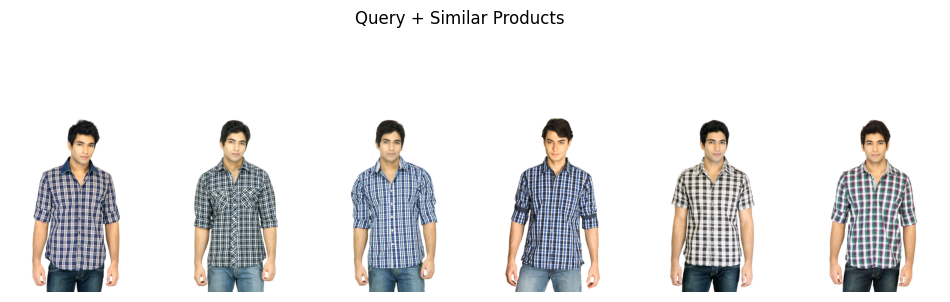

In [85]:
query_index = 0  # you can change this

similar_ids = get_similar_images(query_index, top_k=5)

print("Query Image ID:", valid_ids[query_index])
print("Similar Image IDs:", [valid_ids[i] for i in similar_ids])

show_images([query_index] + similar_ids, title="Query + Similar Products")

In [86]:
import numpy as np

embeddings_norm = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)

print("Normalization done")

Normalization done


In [88]:
from sklearn.metrics.pairwise import cosine_similarity

def get_similar_images(query_index, top_k=5):
    query_embedding = embeddings_norm[query_index].reshape(1, -1)
    
    similarities = cosine_similarity(query_embedding, embeddings_norm)[0]
    
    similar_indices = similarities.argsort()[-(top_k+1):][::-1]
    similar_indices = [i for i in similar_indices if i != query_index][:top_k]
    
    return similar_indices

Query: 15970
Similar: [19176, 19185, 8741, 16395, 15971]


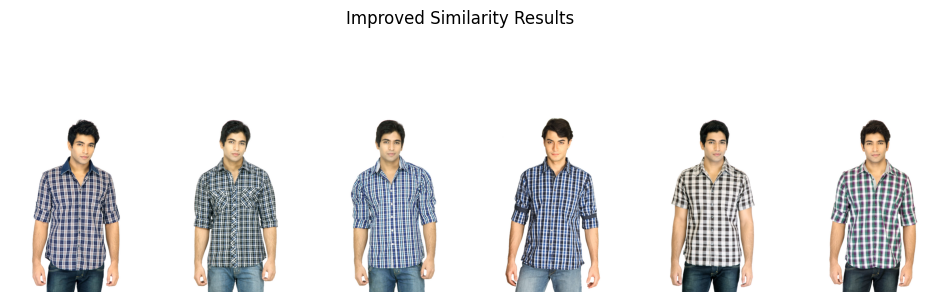

In [89]:
query_index = 0

similar_ids = get_similar_images(query_index)

print("Query:", valid_ids[query_index])
print("Similar:", [valid_ids[i] for i in similar_ids])

show_images([query_index] + similar_ids, title="Improved Similarity Results")

In [91]:
import faiss
import numpy as np

print("FAISS imported successfully")

ModuleNotFoundError: No module named 'faiss'

In [92]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.9 MB/s eta 0:00:00:00:0100:01


In [93]:
import faiss
import numpy as np

print("FAISS imported successfully")

FAISS imported successfully


In [95]:
import numpy as np

# ensure correct type for FAISS
embeddings_np = embeddings_norm.astype('float32')

print("Shape:", embeddings_np.shape)
print("Dtype:", embeddings_np.dtype)

Shape: (5000, 1280)
Dtype: float32


In [96]:
import faiss

dimension = embeddings_np.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings_np)

print("FAISS index built successfully")
print("Total vectors indexed:", index.ntotal)

FAISS index built successfully
Total vectors indexed: 5000


In [100]:
def faiss_retrieve(query_index, top_k=5):
    query_vector = embeddings_np[query_index].reshape(1, -1)
    
    scores, indices = index.search(query_vector, top_k + 1)
    
    # remove itself from results
    results = [i for i in indices[0] if i != query_index][:top_k]
    
    return results

Query ID: 15970
FAISS Results: [19176, 19185, 8741, 16395, 15971]


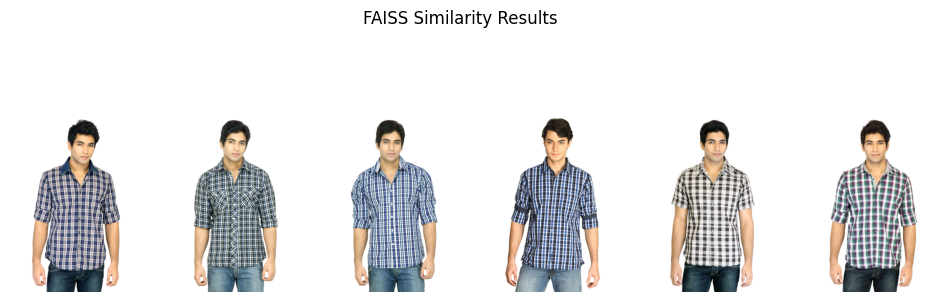

In [101]:
query_index = 0

results = faiss_retrieve(query_index)

print("Query ID:", valid_ids[query_index])
print("FAISS Results:", [valid_ids[i] for i in results])

show_images([query_index] + results, title="FAISS Similarity Results")

In [102]:
from sklearn.manifold import TSNE
import numpy as np

# use embeddings already created
X = embeddings_np[:2000]   # reduce for speed
labels = valid_ids[:2000]

print("Running t-SNE... this may take 1–3 minutes")

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init='random'
)

X_2d = tsne.fit_transform(X)

print("t-SNE completed")
print("Shape:", X_2d.shape)

Running t-SNE... this may take 1–3 minutes
t-SNE completed
Shape: (2000, 2)


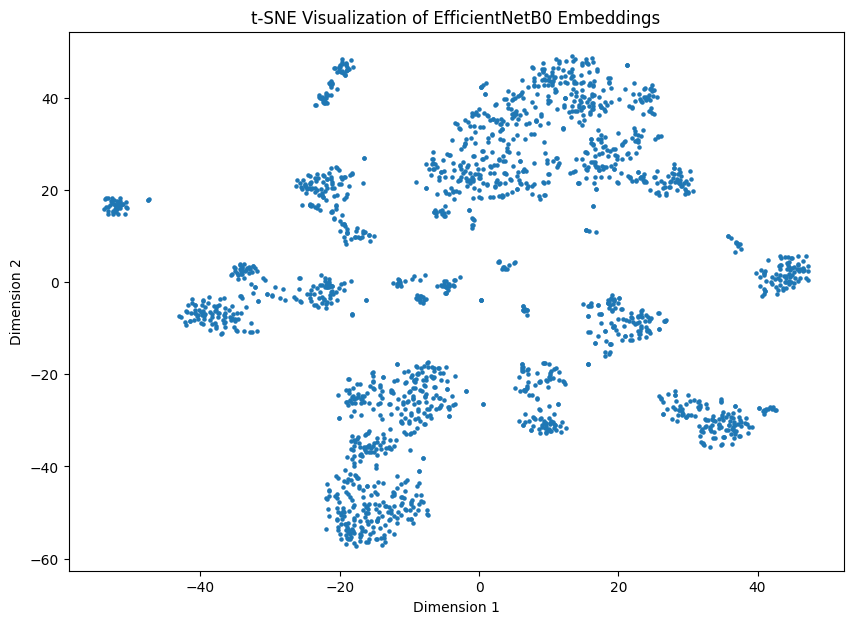

In [103]:
import matplotlib.pyplot as plt

subset_df = df.iloc[:2000].reset_index(drop=True)

plt.figure(figsize=(10, 7))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=5)

plt.title("t-SNE Visualization of EfficientNetB0 Embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

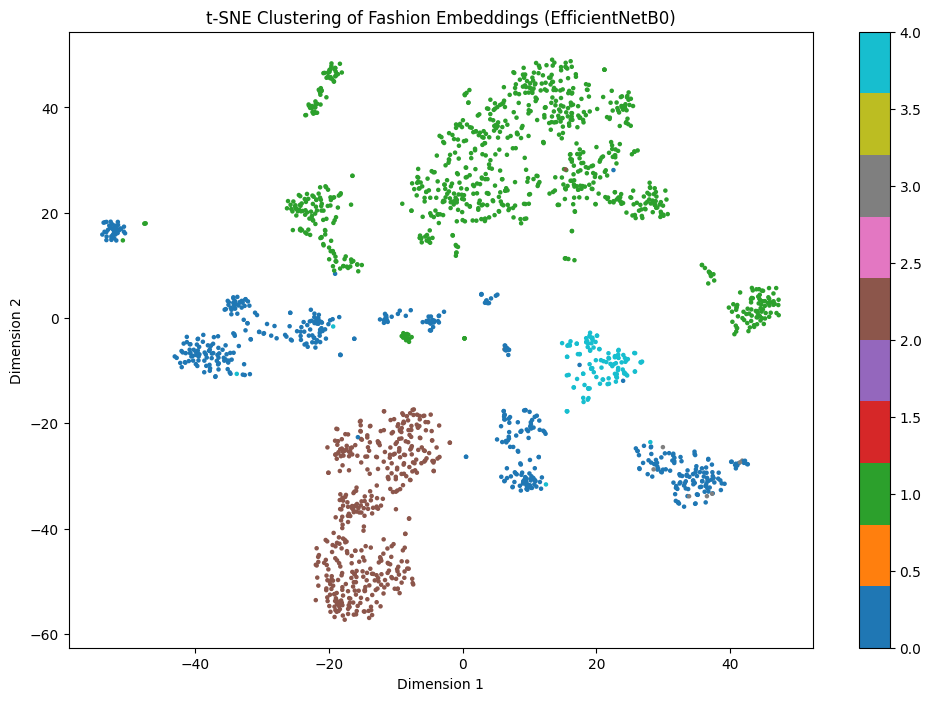

In [104]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

categories = subset_df['masterCategory'].astype('category').cat.codes

plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=categories,
    cmap='tab10',
    s=5
)

plt.title("t-SNE Clustering of Fashion Embeddings (EfficientNetB0)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.colorbar()
plt.show()

In [106]:
import pandas as pd
import numpy as np

# map id → category
id_to_category = dict(zip(df['id'], df['masterCategory']))

print("Mapping ready")

Mapping ready


In [108]:
def precision_at_k(query_index, top_k=5):
    query_id = valid_ids[query_index]
    query_category = id_to_category.get(query_id, None)
    
    retrieved = faiss_retrieve(query_index, top_k)
    
    if query_category is None:
        return None
    
    relevant = 0
    
    for idx in retrieved:
        retrieved_id = valid_ids[idx]
        retrieved_category = id_to_category.get(retrieved_id, None)
        
        if retrieved_category == query_category:
            relevant += 1
    
    return relevant / top_k

In [109]:
sample_indices = np.random.choice(len(valid_ids), 200, replace=False)

scores = []

for i in sample_indices:
    score = precision_at_k(i, top_k=5)
    if score is not None:
        scores.append(score)

print("Average Precision@5:", np.mean(scores))

Average Precision@5: 0.9919999999999999


In [110]:
from collections import defaultdict

category_scores = defaultdict(list)

for i in sample_indices[:100]:
    query_id = valid_ids[i]
    query_category = id_to_category.get(query_id, None)
    
    retrieved = faiss_retrieve(i, 5)
    
    match = 0
    for r in retrieved:
        rid = valid_ids[r]
        if id_to_category.get(rid) == query_category:
            match += 1
    
    if query_category:
        category_scores[query_category].append(match / 5)

for cat, scores in category_scores.items():
    print(cat, "->", round(np.mean(scores), 3))

Apparel -> 1.0
Accessories -> 0.942
Footwear -> 1.0
Personal Care -> 1.0
